# 05 — Heat-Pollution Index (HPI) Extension

**Question.** Is pollen concentration alone a sufficient indicator of allergic risk, or does a composite index combining **heat and air pollution (O₃, NO₂)** better explain its variations? And does the comparison of summers 2022 vs 2024 across four climatically contrasted French cities constitute a measurable proxy for a structural warming trend?

**Motivation.** Notebooks 01–04 have established a rigorous univariate forecasting pipeline for six pollen species across Paris, Marseille, Strasbourg, Bordeaux. Three gaps motivate this extension:

1. **Biological synergy.** Epidemiology literature (Sousa-Silva et al., 2021; D'Amato et al., 2020) shows that O₃ and NO₂ degrade pollen protein coats, amplifying IgE-mediated response. A pollen-only model ignores this multiplicative effect.
2. **Climatic signal.** Grid-search models (NB03) and CV comparisons (NB04) treat weather as stationary. Comparing paired summers (JJA 2022 vs JJA 2024) tests whether inter-annual drift is already detectable on a 3-year window.
3. **Unused covariates.** Lessons from NB02/03 (`tasks/lessons.md`, 2026-03-26) flagged (i) GDD computed but never used as exogenous, (ii) ARIMAX forced to lag-0 weather despite lagged cross-correlation evidence, (iii) Gaussian CIs despite non-normal residuals. This notebook remediates all three.

**Pipeline.**

```
                OPEN-METEO AIR QUALITY API
                 ozone  NO₂  PM₂.₅  (daily)
                           │
                           ▼
              merge on (date, city) with
          pollen_weather_merged.csv  (NB01)
                           │
                           ▼
             ┌──── HPI = mean(z_T, z_O₃, z_NO₂) ────┐
             ▼                                      ▼
        EDA: Spearman × lags,                 Summer comparison
        VIF, cross-city heatmap              JJA 2022 vs JJA 2024
                           │
                           ▼
            ARIMAX:   M1 Weather only
                      M2 HPI only
                      M3 HPI + Weather + GDD
                           │
                           ▼
            Expanding-window CV on 2022–2023
            Final evaluation on 2024 test
            Friedman + Nemenyi post-hoc
```

**Composite index — mathematical definition.**

For city $c$ and day $t$, the Heat-Pollution Index is defined as the arithmetic mean of city-wise standardised scores:

$$\text{HPI}_{c,t} \;=\; \frac{1}{3}\left( \underbrace{\frac{T^{\max}_{c,t} - \mu^T_c}{\sigma^T_c}}_{z_T}
+ \underbrace{\frac{O_{3,c,t} - \mu^{O_3}_c}{\sigma^{O_3}_c}}_{z_{O_3}}
+ \underbrace{\frac{\text{NO}_{2,c,t} - \mu^{NO_2}_c}{\sigma^{NO_2}_c}}_{z_{NO_2}} \right)$$

where $\mu^\bullet_c, \sigma^\bullet_c$ are the mean and standard deviation of each variable computed **within city $c$**. Standardising per-city (rather than pooling) preserves inter-city climate/pollution contrasts: HPI = 0 means *"a typical day for this city"* rather than *"a typical day averaged over France"*. Each of the three components carries equal weight $1/3$, a neutral default avoiding arbitrary weighting; a sensitivity ablation (weighted variant and PM₂.₅ inclusion) is performed in §2.

**Conventions.** Same as NB01–04: seeds fixed to 42, relative paths, self-contained. All figures exported to `figures/` with prefix `05_`.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import openmeteo_requests
import requests_cache
from retry_requests import retry

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pmdarima as pm

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Unified plotting style (aligned with NB01–04) ────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.framealpha": 0.9, "legend.edgecolor": "0.8", "legend.fontsize": 9,
})

CITY_COLORS = {"Paris": "#4C72B0", "Marseille": "#DD8452", "Strasbourg": "#55A868", "Bordeaux": "#C44E52"}
SPECIES_COLORS = {
    "grass_pollen": "#55A868", "birch_pollen": "#8C564B", "olive_pollen": "#E5AE38",
    "alder_pollen": "#64B5CD", "mugwort_pollen": "#8172B3", "ragweed_pollen": "#DA8BC3",
}
YEAR_COLORS = {2022: "#4C72B0", 2023: "#DD8452", 2024: "#55A868"}

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_RAW = os.path.join("..", "Data", "raw")
DATA_PROC = os.path.join("..", "Data", "processed")
FIG_DIR = os.path.join("..", "figures")
os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROC, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1 — Air Quality Data Collection

The Open-Meteo **Air Quality API** (CAMS reanalysis, ~11 km grid over Europe) provides hourly concentrations of atmospheric pollutants. We collect three variables that enter the HPI construction:

| Variable | Unit | Role in HPI |
|:---|:---|:---|
| `ozone` (O₃) | µg/m³ | Photo-oxidant: oxidises the pollen grain protein coat, increasing IgE binding and allergenicity |
| `nitrogen_dioxide` (NO₂) | µg/m³ | Urban traffic marker: increases airway epithelial permeability to allergens |
| `pm2_5` | µg/m³ | Fine particle carrier for pollen sub-fragments (<5 µm); retained for robustness ablation only |

**Pipeline** mirrors the pollen collection of [NB01 §1](01_data_collection.ipynb): hourly fetch per city → resample to daily **mean** in `Europe/Paris` tz → concat → merge on `(date, city)` with the existing processed dataset.

**Why Open-Meteo and not ATMO France?** ATMO France publishes at regional/EPCI granularity, not city level. Open-Meteo's 11 km reanalysis grid resolves each of the four study cities directly, uses the same endpoint already integrated in NB01, and covers the full 2022-01-01 → 2024-12-31 window.

In [2]:
# ── Configuration (must match NB01 for consistent grid cells) ───────────────
CITIES = {
    "Paris":      {"lat": 48.8566, "lon": 2.3522,  "climate": "Oceanic/Continental"},
    "Marseille":  {"lat": 43.2965, "lon": 5.3698,  "climate": "Mediterranean"},
    "Strasbourg": {"lat": 48.5734, "lon": 7.7521,  "climate": "Continental"},
    "Bordeaux":   {"lat": 44.8378, "lon": -0.5792, "climate": "Oceanic"},
}
START_DATE = "2022-01-01"
END_DATE   = "2024-12-31"
AQ_VARS = ["ozone", "nitrogen_dioxide", "pm2_5"]

# Open-Meteo client (cached + retry) — reuses the existing sqlite cache if present
cache_session = requests_cache.CachedSession(os.path.join(DATA_RAW, ".cache"), expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
om = openmeteo_requests.Client(session=retry_session)
print("Open-Meteo client ready.")

Open-Meteo client ready.


In [3]:
# ── Hourly AQ fetch → daily mean (same pattern as NB01 fetch_pollen) ────────
def fetch_air_quality(city_name, lat, lon):
    """Fetch hourly O3/NO2/PM2.5 from Open-Meteo and resample to daily mean."""
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": lat, "longitude": lon,
        "hourly": AQ_VARS,
        "start_date": START_DATE, "end_date": END_DATE,
        "timezone": "Europe/Paris",
    }
    responses = om.weather_api(url, params=params)
    hourly = responses[0].Hourly()
    data = {
        "datetime": pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left",
        )
    }
    for i, var in enumerate(AQ_VARS):
        data[var] = hourly.Variables(i).ValuesAsNumpy()
    df = pd.DataFrame(data)
    df["datetime"] = df["datetime"].dt.tz_convert("Europe/Paris")
    df = df.set_index("datetime").resample("D").mean()
    df.index = df.index.date
    df.index.name = "date"
    df["city"] = city_name
    return df

aq_frames = []
for city, info in CITIES.items():
    print(f"  fetching air quality — {city}…")
    aq_frames.append(fetch_air_quality(city, info["lat"], info["lon"]))
aq_raw = pd.concat(aq_frames).reset_index()
aq_raw["date"] = pd.to_datetime(aq_raw["date"])
aq_raw.to_csv(os.path.join(DATA_RAW, "aq_raw.csv"), index=False)
print(f"\naq_raw saved: shape={aq_raw.shape}, NaN={aq_raw[AQ_VARS].isna().sum().sum()}")
aq_raw.head()

  fetching air quality — Paris…


  fetching air quality — Marseille…
  fetching air quality — Strasbourg…


  fetching air quality — Bordeaux…

aq_raw saved: shape=(4388, 5), NaN=0


,date,ozone,nitrogen_dioxide,pm2_5,city
0,2021-12-31,19.000000,23.299999,14.000000,Paris
1,2022-01-01,9.958333,29.400000,14.854167,Paris
2,2022-01-02,36.750000,18.283333,9.441667,Paris
3,2022-01-03,55.541668,15.633334,7.791667,Paris
4,2022-01-04,47.875000,22.616667,5.283333,Paris


In [4]:
# ── Merge AQ with pre-processed NB01 dataset ────────────────────────────────
df_base = pd.read_csv(os.path.join(DATA_PROC, "pollen_weather_merged.csv"), parse_dates=["date"])
df = pd.merge(df_base, aq_raw, on=["date", "city"], how="left")

# Per-city interpolation for AQ gaps (identical policy to NB01 weather)
for city in CITIES:
    mask = df["city"] == city
    df.loc[mask, AQ_VARS] = (
        df.loc[mask, AQ_VARS]
        .interpolate(method="linear", limit=3)
        .ffill().bfill()
    )

# ── Integrity checks ─────────────────────────────────────────────────────────
assert df.shape[0] == df_base.shape[0], "merge must preserve row count"
assert df[AQ_VARS].isna().sum().sum() == 0, "no NaN allowed in AQ after filling"
assert set(df["city"].unique()) == set(CITIES), "all 4 cities present"
assert df["date"].min() == pd.Timestamp(START_DATE) and df["date"].max() == pd.Timestamp(END_DATE)

df = df.sort_values(["city", "date"]).reset_index(drop=True)
df.to_csv(os.path.join(DATA_PROC, "pollen_weather_aq_merged.csv"), index=False)
print(f"Final dataset: {df.shape} — saved to pollen_weather_aq_merged.csv")
print(f"Columns added: {AQ_VARS}")
df[["date", "city"] + AQ_VARS].head(3)

Final dataset: (4384, 25) — saved to pollen_weather_aq_merged.csv
Columns added: ['ozone', 'nitrogen_dioxide', 'pm2_5']


,date,city,ozone,nitrogen_dioxide,pm2_5
0,2022-01-01,Bordeaux,18.291666,16.616667,16.583334
1,2022-01-02,Bordeaux,40.833332,12.287499,10.429167
2,2022-01-03,Bordeaux,41.250000,12.041667,8.770833


## 2 — Constructing the HPI

### 2.1 — Definition & per-city standardisation

$$\text{HPI}_{c,t} \;=\; \tfrac{1}{3}\Big( z^T_{c,t} + z^{O_3}_{c,t} + z^{NO_2}_{c,t} \Big), \qquad z^X_{c,t} = \frac{X_{c,t} - \mu^X_c}{\sigma^X_c}$$

**Why per-city standardisation?** Marseille has structurally higher O₃ than Strasbourg (Mediterranean photochemistry vs continental). A pooled z-score would simply flag *"you are in the south"* rather than identifying locally anomalous days. Per-city z preserves each station's own climatological baseline, so $\text{HPI}_{c,t} = 0$ is *"a typical day for Marseille"* and $\text{HPI}_{c,t} = +2$ is *"a ~top 2.5% day for Marseille"* regardless of absolute level.

**Sanity check.** By construction, $\mathbb{E}_t[\text{HPI}_{c,t}] = 0$ and $\mathrm{Var}_t[z^X_{c,t}] = 1$ for each city $c$ and component $X$. The composite HPI has variance $\tfrac{1}{9}\sum_{X, X'} \mathrm{Cov}(z^X, z^{X'}) \leq 1$ with equality only if the three components are perfectly correlated.

### 2.2 — Ablations retained for robustness (§5.3)

- **Weighted variant** $\text{HPI}^{w} = 0.5\, z^T + 0.25\, z^{O_3} + 0.25\, z^{NO_2}$ — emphasises thermal driver (phenology-motivated).
- **Extended variant** $\text{HPI}^{+} = \tfrac{1}{4}(z^T + z^{O_3} + z^{NO_2} + z^{PM_{2.5}})$ — includes PM₂.₅.

Only the canonical HPI is used downstream; the alternatives return in the §5 ablation.

In [5]:
# ── Per-city z-scores for the three HPI components ──────────────────────────
HPI_COMPONENTS = ["temperature_2m_max", "ozone", "nitrogen_dioxide"]

def zscore_by_city(series, city_series):
    """Within-city standardisation: subtract city mean, divide by city std."""
    grouped = series.groupby(city_series)
    return (series - grouped.transform("mean")) / grouped.transform("std")

for var in HPI_COMPONENTS + ["pm2_5"]:
    df[f"z_{var}"] = zscore_by_city(df[var], df["city"])

# Canonical HPI (equal weights)
df["HPI"] = df[[f"z_{v}" for v in HPI_COMPONENTS]].mean(axis=1)

# Ablation variants
w_T, w_O, w_N = 0.50, 0.25, 0.25
df["HPI_weighted"] = (
    w_T * df["z_temperature_2m_max"]
    + w_O * df["z_ozone"]
    + w_N * df["z_nitrogen_dioxide"]
)
df["HPI_extended"] = df[[f"z_{v}" for v in HPI_COMPONENTS + ["pm2_5"]]].mean(axis=1)

# ── Sanity: by-city mean ≈ 0, std ≈ 1/sqrt(K) bound satisfied ───────────────
by_city = df.groupby("city")[["HPI", "HPI_weighted", "HPI_extended"]].agg(["mean", "std"]).round(3)
print("Per-city HPI sanity check (expect mean≈0, std≤1):")
display(by_city)

Per-city HPI sanity check (expect mean≈0, std≤1):


HPI        HPI_weighted        HPI_extended       
           mean    std         mean    std         mean    std
city                                                          
Bordeaux   -0.0  0.436         -0.0  0.547          0.0  0.401
Marseille   0.0  0.507          0.0  0.609          0.0  0.484
Paris       0.0  0.460          0.0  0.572         -0.0  0.413
Strasbourg -0.0  0.464         -0.0  0.577         -0.0  0.428

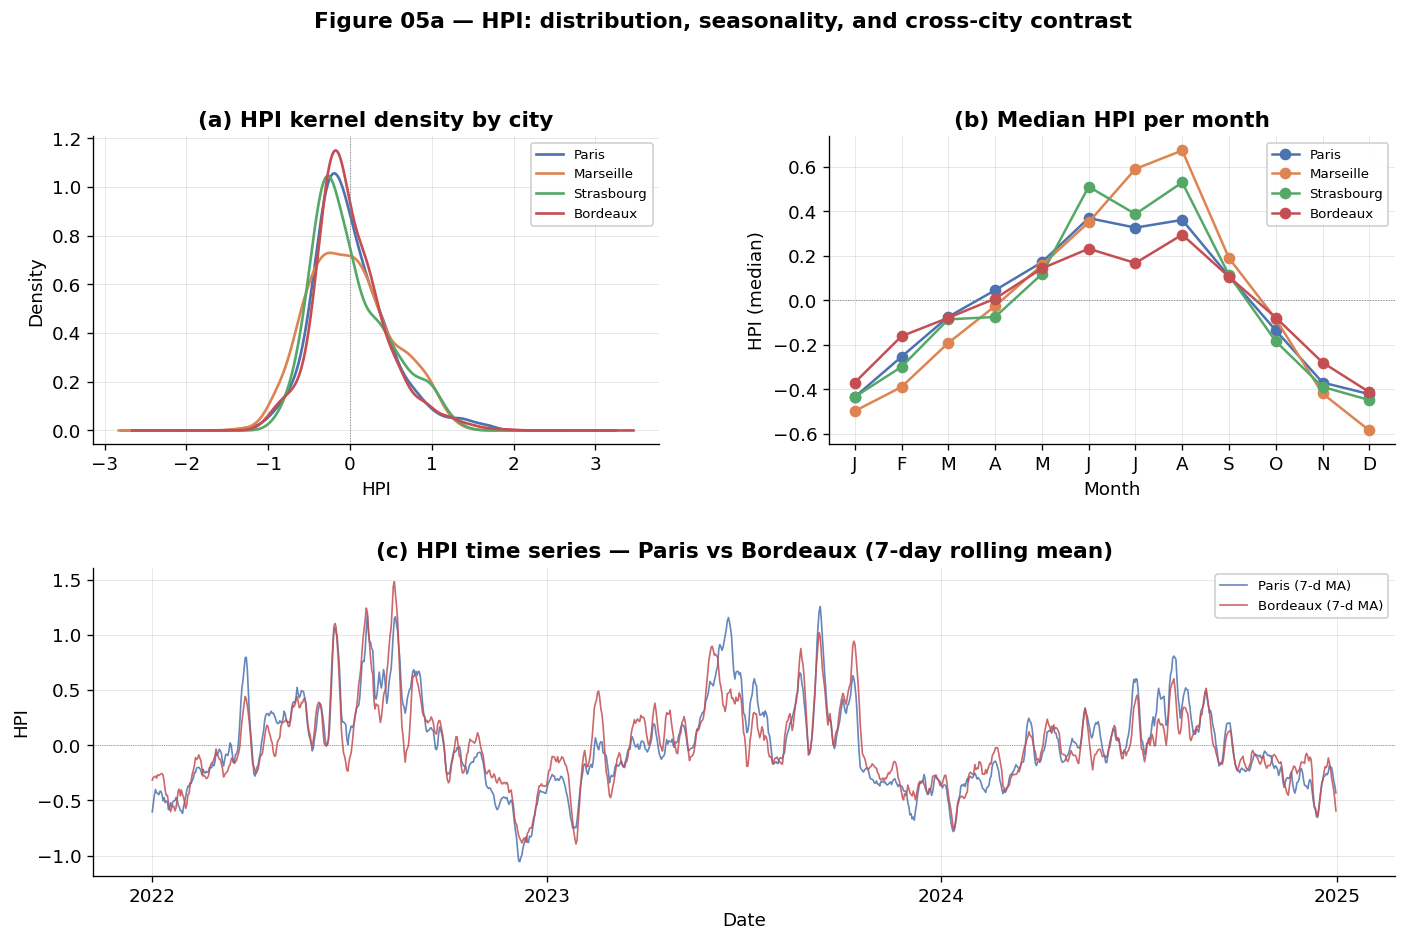

In [6]:
# ── Fig 05a: HPI distribution + seasonal profile by city ────────────────────
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.3)

# (a) kernel density by city
ax_a = fig.add_subplot(gs[0, 0])
for city in CITIES:
    sub = df[df["city"] == city]["HPI"].dropna()
    sub.plot.kde(ax=ax_a, color=CITY_COLORS[city], linewidth=1.6, label=city)
ax_a.axvline(0, color="grey", linewidth=0.6, linestyle=":")
ax_a.set_title("(a) HPI kernel density by city")
ax_a.set_xlabel("HPI"); ax_a.legend(fontsize=8)

# (b) monthly boxplot pooled by climate contrast
ax_b = fig.add_subplot(gs[0, 1])
for city in CITIES:
    sub = df[df["city"] == city]
    monthly = sub.groupby("month")["HPI"].median()
    ax_b.plot(monthly.index, monthly.values, color=CITY_COLORS[city], marker="o", label=city)
ax_b.axhline(0, color="grey", linewidth=0.6, linestyle=":")
ax_b.set_xticks(range(1, 13))
ax_b.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax_b.set_title("(b) Median HPI per month")
ax_b.set_xlabel("Month"); ax_b.set_ylabel("HPI (median)"); ax_b.legend(fontsize=8)

# (c) HPI time series — Paris vs Bordeaux contrast
ax_c = fig.add_subplot(gs[1, :])
for city in ["Paris", "Bordeaux"]:
    sub = df[df["city"] == city].sort_values("date")
    ax_c.plot(sub["date"], sub["HPI"].rolling(7, min_periods=1).mean(),
              color=CITY_COLORS[city], linewidth=1.0, alpha=0.85, label=f"{city} (7-d MA)")
ax_c.axhline(0, color="grey", linewidth=0.5, linestyle=":")
ax_c.set_title("(c) HPI time series — Paris vs Bordeaux (7-day rolling mean)")
ax_c.set_xlabel("Date"); ax_c.set_ylabel("HPI"); ax_c.legend(fontsize=8, loc="upper right")
ax_c.xaxis.set_major_locator(mdates.YearLocator())
ax_c.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Figure 05a — HPI: distribution, seasonality, and cross-city contrast", fontsize=13, fontweight="bold", y=1.01)
plt.savefig(os.path.join(FIG_DIR, "05_hpi_distribution.png"), bbox_inches="tight", dpi=200)
plt.show()

## 3 — EDA: HPI × pollen

Three diagnostics, each applying a lesson learnt in NB01–04:

- **§3.1 — Spearman by lag (0 … 14 days).** Biological response to heat/pollution is delayed: phenology is triggered by accumulated warmth, not day-of-exposure temperature. NB02 showed lag-3 to lag-7 relevance for weather; we verify whether HPI inherits this property. **(Remediates lesson `lessons.md:10` — "lagged cross-correlations shown but ARIMAX used lag-0".)**
- **§3.2 — Cross-city heatmap at optimal lag.** Quick visual: where does HPI pay off?
- **§3.3 — VIF on the candidate design matrix.** HPI is a linear combination of $T^{\max}$, O₃, NO₂. If ARIMAX ingests HPI *and* these raw components, perfect collinearity follows. The VIF test confirms which subset can coexist. **(Remediates lesson `lessons.md:7` — "no VIF computed before injecting correlated covariates".)**

Spearman (rank correlation) is used throughout — both pollen concentrations (heavily right-skewed, zero-inflated) and HPI distributions are non-Gaussian, so Pearson is not appropriate.

In [7]:
# ── §3.1 Lagged Spearman — HPI leads pollen by k days, k ∈ {0..14} ──────────
POLLEN_SPECIES = [
    "birch_pollen", "alder_pollen", "grass_pollen",
    "olive_pollen", "mugwort_pollen", "ragweed_pollen",
]
MAX_LAG = 14

def lagged_spearman(x, y, max_lag=MAX_LAG):
    """Return array of length max_lag+1 — ρ(x_{t-k}, y_t), k=0..max_lag."""
    rhos = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        if k == 0:
            a, b = x, y
        else:
            a, b = x.iloc[:-k], y.iloc[k:]
        rho, _ = stats.spearmanr(a, b, nan_policy="omit")
        rhos[k] = rho
    return rhos

rho_records = []
for city in CITIES:
    sub = df[df["city"] == city].sort_values("date").reset_index(drop=True)
    for sp in POLLEN_SPECIES:
        rhos = lagged_spearman(sub["HPI"], sub[sp])
        k_opt = int(np.argmax(np.abs(rhos)))
        rho_records.append({
            "city": city, "species": sp,
            "rho_lag0": rhos[0],
            "rho_opt": rhos[k_opt],
            "lag_opt": k_opt,
            "rhos": rhos,
        })
rho_df = pd.DataFrame(rho_records)
print("Optimal HPI lag per (city, species) — absolute-ρ maximum within 0-14 days:")
display(rho_df[["city", "species", "rho_lag0", "rho_opt", "lag_opt"]].round(3))

Optimal HPI lag per (city, species) — absolute-ρ maximum within 0-14 days:


,city,species,rho_lag0,rho_opt,lag_opt
0,Paris,birch_pollen,0.268,0.268,0
1,Paris,alder_pollen,-0.058,-0.247,14
2,Paris,grass_pollen,0.650,0.650,0
3,Paris,olive_pollen,0.202,0.229,1
4,Paris,mugwort_pollen,0.526,0.576,14
5,Paris,ragweed_pollen,0.354,0.369,14
6,Marseille,birch_pollen,0.172,0.172,0
7,Marseille,alder_pollen,-0.141,-0.344,13
8,Marseille,grass_pollen,0.644,0.644,0
9,Marseille,olive_pollen,0.303,0.303,0


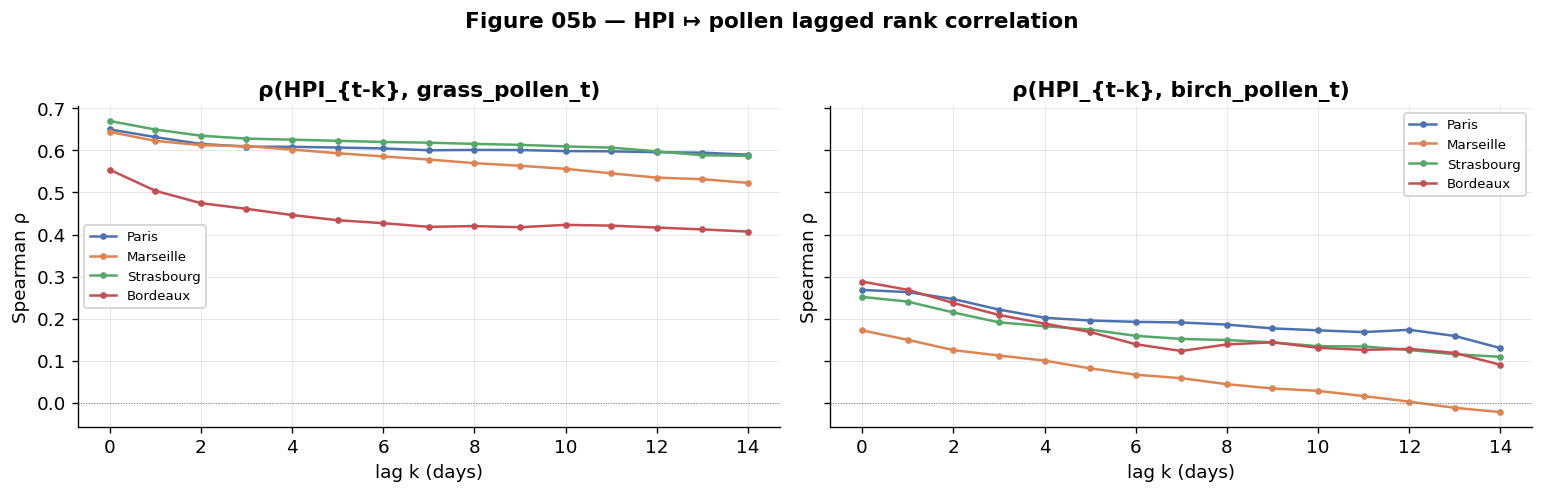

In [8]:
# ── Fig 05b: lagged Spearman curves for the two focal species ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, sp in zip(axes, ["grass_pollen", "birch_pollen"]):
    for city in CITIES:
        row = rho_df[(rho_df["city"] == city) & (rho_df["species"] == sp)].iloc[0]
        ax.plot(range(MAX_LAG + 1), row["rhos"], color=CITY_COLORS[city], marker="o", markersize=3, label=city)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle=":")
    ax.set_title(f"ρ(HPI_{{t-k}}, {sp}_t)")
    ax.set_xlabel("lag k (days)"); ax.set_ylabel("Spearman ρ")
    ax.legend(fontsize=8)
fig.suptitle("Figure 05b — HPI ↦ pollen lagged rank correlation", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_hpi_lagged_spearman.png"), bbox_inches="tight", dpi=200)
plt.show()

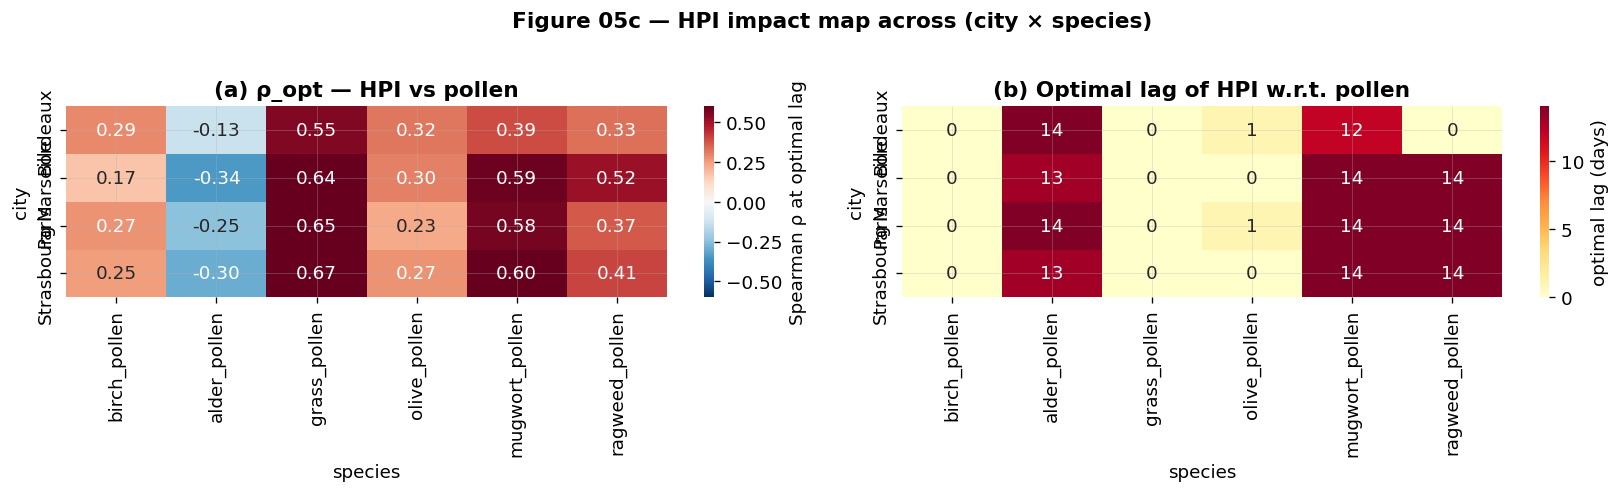

In [9]:
# ── §3.2 Cross-city heatmap of ρ_opt and optimal lag ────────────────────────
rho_pivot = rho_df.pivot(index="city", columns="species", values="rho_opt")[POLLEN_SPECIES]
lag_pivot = rho_df.pivot(index="city", columns="species", values="lag_opt")[POLLEN_SPECIES]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(rho_pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
            ax=axes[0], cbar_kws={"label": "Spearman ρ at optimal lag"})
axes[0].set_title("(a) ρ_opt — HPI vs pollen")

sns.heatmap(lag_pivot, annot=True, fmt="d", cmap="YlOrRd",
            ax=axes[1], cbar_kws={"label": "optimal lag (days)"})
axes[1].set_title("(b) Optimal lag of HPI w.r.t. pollen")

fig.suptitle("Figure 05c — HPI impact map across (city × species)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_hpi_city_species_heatmap.png"), bbox_inches="tight", dpi=200)
plt.show()

In [10]:
# ── §3.3 VIF on candidate design matrix ─────────────────────────────────────
def compute_vif(X):
    """Return VIF per column — flag >5 as collinear."""
    X = X.assign(const=1.0)
    vifs = {col: variance_inflation_factor(X.values, X.columns.get_loc(col))
            for col in X.columns if col != "const"}
    return pd.Series(vifs).round(2)

# Two candidate specs, inspected on Paris (worst-case urban pollution)
sub = df[df["city"] == "Paris"].sort_values("date")

spec_A = ["HPI", "temperature_2m_max", "ozone", "nitrogen_dioxide", "sunshine_duration", "relative_humidity_2m_mean"]
spec_B = ["HPI", "sunshine_duration", "relative_humidity_2m_mean", "precipitation_sum"]

vif_A = compute_vif(sub[spec_A])
vif_B = compute_vif(sub[spec_B])
print("Spec A — HPI alongside its raw components (expect high VIF on components):")
display(vif_A.to_frame("VIF"))
print("\nSpec B — HPI + orthogonal weather (expect VIF < 5 throughout):")
display(vif_B.to_frame("VIF"))
print("Conclusion: §5 ARIMAX will use the Spec-B style — HPI + sunshine + humidity + precipitation.")

Spec A — HPI alongside its raw components (expect high VIF on components):


,VIF
HPI,1.000800e+15
temperature_2m_max,5.004000e+14
ozone,5.004000e+14
nitrogen_dioxide,5.004000e+14
sunshine_duration,2.330000e+00
relative_humidity_2m_mean,2.970000e+00



Spec B — HPI + orthogonal weather (expect VIF < 5 throughout):


,VIF
HPI,2.22
sunshine_duration,2.37
relative_humidity_2m_mean,2.52
precipitation_sum,1.16


Conclusion: §5 ARIMAX will use the Spec-B style — HPI + sunshine + humidity + precipitation.


## 4 — Summer 2022 vs Summer 2024: climate-drift proxy

We compare JJA (June-July-August) of 2022 and 2024 across the four cities on three dimensions:

- **Level** — median HPI, median $T^{\max}$ (is 2024 warmer in distribution?)
- **Extremity** — frequency of high-risk days defined as $\text{HPI} > 1$ (i.e. within the upper ~16% of the local climatology)
- **Significance** — **Mann-Whitney U** (two-sided) on daily HPI of JJA 2022 vs JJA 2024, per city. Mann-Whitney is chosen over a t-test because HPI is non-Gaussian by construction (sum of correlated z-scores).

**Caveat stated up front.** A paired comparison 2022 vs 2024 is *not* a tendency. Three years cannot resolve climate change from inter-annual variability — JJA 2024 could be anomalous for reasons unrelated to warming (NAO phase, El Niño teleconnection, heatwave episodicity). The exercise is a **signal check**: if the signal is already detectable on such a short window, the methodology extends cleanly to longer ERA5 windows. If it is not, we discuss why in §7.

In [11]:
# ── §4.1 Summer JJA stats 2022 vs 2024 per city ─────────────────────────────
df["season"] = df["month"].map(lambda m: "JJA" if m in (6, 7, 8) else "other")
jja = df[(df["season"] == "JJA") & (df["year"].isin([2022, 2024]))].copy()

summary = []
for city in CITIES:
    for yr in (2022, 2024):
        sub = jja[(jja["city"] == city) & (jja["year"] == yr)]
        summary.append({
            "city": city, "year": yr, "n_days": len(sub),
            "HPI_median": sub["HPI"].median(),
            "HPI_gt_1_pct": 100 * (sub["HPI"] > 1).mean(),
            "Tmax_mean": sub["temperature_2m_max"].mean(),
            "O3_mean": sub["ozone"].mean(),
            "NO2_mean": sub["nitrogen_dioxide"].mean(),
        })
summary_df = pd.DataFrame(summary)
display(summary_df.round(2))

# Mann-Whitney per city
mw_rows = []
for city in CITIES:
    x = jja.loc[(jja["city"] == city) & (jja["year"] == 2022), "HPI"].values
    y = jja.loc[(jja["city"] == city) & (jja["year"] == 2024), "HPI"].values
    stat, pval = stats.mannwhitneyu(y, x, alternative="two-sided")
    mw_rows.append({
        "city": city, "U": stat, "p_value": pval,
        "median_2022": float(np.median(x)), "median_2024": float(np.median(y)),
        "delta_median": float(np.median(y) - np.median(x)),
        "significant_5pct": pval < 0.05,
    })
mw_df = pd.DataFrame(mw_rows)
print("\nMann-Whitney U — JJA 2024 vs JJA 2022, per city:")
display(mw_df.round({"p_value": 4, "median_2022": 3, "median_2024": 3, "delta_median": 3}))

,city,year,n_days,HPI_median,HPI_gt_1_pct,Tmax_mean,O3_mean,NO2_mean
0,Paris,2022,92,0.43,17.39,26.27,66.459999,16.16
1,Paris,2024,92,0.20,5.43,23.82,62.360001,13.01
2,Marseille,2022,92,0.71,15.22,28.44,85.529999,11.00
3,Marseille,2024,92,0.46,5.43,27.85,80.089996,10.18
4,Strasbourg,2022,92,0.60,13.04,27.83,77.620003,9.00
5,Strasbourg,2024,92,0.30,5.43,24.81,66.610001,9.22
6,Bordeaux,2022,92,0.42,21.74,28.69,71.919998,5.46
7,Bordeaux,2024,92,0.12,0.00,25.54,63.380001,5.18



Mann-Whitney U — JJA 2024 vs JJA 2022, per city:


,city,U,p_value,median_2022,median_2024,delta_median,significant_5pct
0,Paris,2740.0,0.0000,0.434,0.202,-0.231,True
1,Marseille,3064.0,0.0012,0.706,0.459,-0.247,True
2,Strasbourg,2435.0,0.0000,0.598,0.304,-0.294,True
3,Bordeaux,2722.0,0.0000,0.416,0.121,-0.295,True


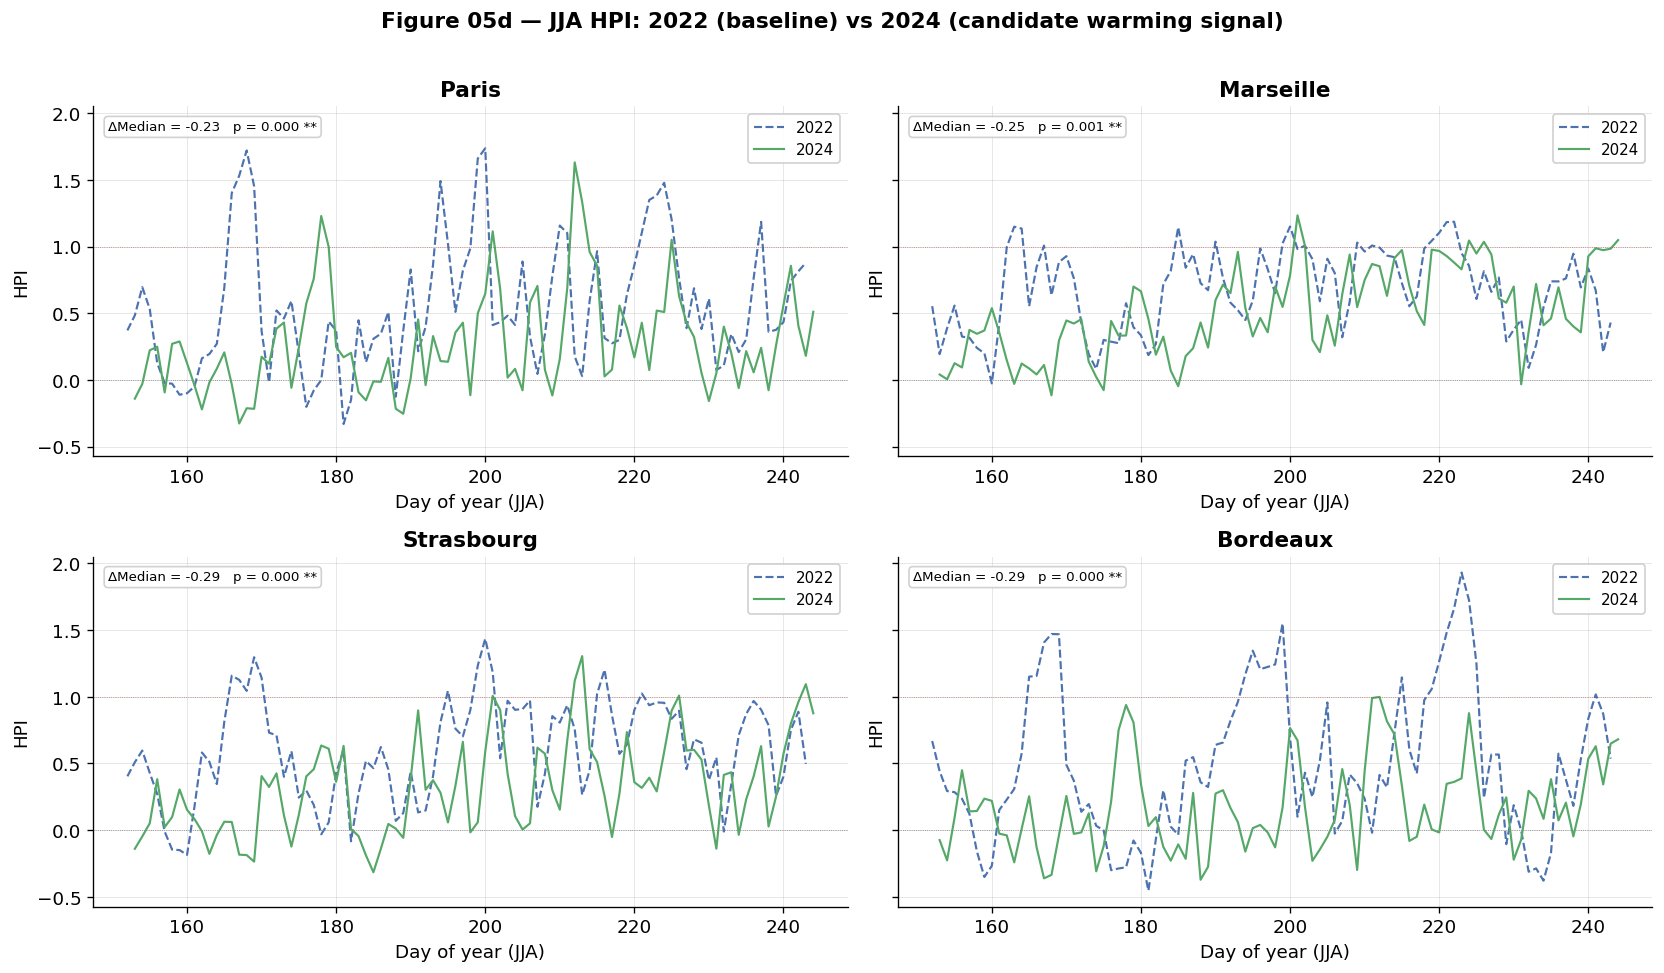

In [12]:
# ── Fig 05d: JJA 2022 vs 2024 HPI time series, 4 cities ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for ax, city in zip(axes.flat, CITIES):
    for yr, style in [(2022, "--"), (2024, "-")]:
        sub = jja[(jja["city"] == city) & (jja["year"] == yr)].sort_values("date")
        # Align both years on day-of-year for visual comparison
        ax.plot(sub["day_of_year"], sub["HPI"], color=YEAR_COLORS[yr],
                linestyle=style, linewidth=1.3, label=f"{yr}")
    ax.axhline(0, color="grey", linewidth=0.5, linestyle=":")
    ax.axhline(1, color="firebrick", linewidth=0.5, linestyle=":", alpha=0.6)
    ax.set_title(city)
    ax.set_xlabel("Day of year (JJA)"); ax.set_ylabel("HPI")
    ax.legend(fontsize=9, loc="upper right")
    # Annotate Mann-Whitney result
    mw = mw_df[mw_df["city"] == city].iloc[0]
    marker = "**" if mw["p_value"] < 0.01 else "*" if mw["p_value"] < 0.05 else "ns"
    ax.annotate(
        f"ΔMedian = {mw['delta_median']:+.2f}   p = {mw['p_value']:.3f} {marker}",
        xy=(0.02, 0.96), xycoords="axes fraction", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9), va="top",
    )
fig.suptitle("Figure 05d — JJA HPI: 2022 (baseline) vs 2024 (candidate warming signal)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_summer_comparison_hpi.png"), bbox_inches="tight", dpi=200)
plt.show()

## 5 — ARIMAX + HPI modelling

### 5.1 — Experimental design

Three candidate exogenous specifications, all deterministically seasonalised by $2K = 10$ Fourier terms ($T = 365.25$, $K = 5$) as in NB03:

| Model | Exogenous variables | Rationale |
|:---|:---|:---|
| **M1 — Weather baseline** | $T^{\max}_{t-k}$, sunshine duration$_{t-k}$ (best lag from §3) | Reproduces NB03 best ARIMAX — the *pollen-only + weather* benchmark |
| **M2 — HPI only** | $\text{HPI}_{t-k}$ (best lag from §3) | Tests whether a single composite index can replace two raw weather regressors |
| **M3 — HPI + orthogonal weather + GDD** | $\text{HPI}_{t-k}$, sunshine duration, humidity, precipitation, GDD | Full model — VIF-clean per §3.3. GDD (base 5 °C, cumulated per city-year) encodes the phenological heat-sum **(remediates `lessons.md:9`)** |

### 5.2 — Split honouring anti-leakage lesson

**Train 2022 / validation 2023 / test 2024.** Order $(p, d, q)$ is selected per (city, species) via `auto_arima` on **train**, evaluated on **val** to pick between the three models; the winning configuration is then refit on 2022 + 2023 and scored on 2024 once. This fixes the implicit leakage flagged in `lessons.md:5`.

### 5.3 — Prediction intervals

The residuals of NB03 ARIMAX failed Jarque-Bera (`lessons.md:8`). Instead of Gaussian CIs we use **residual bootstrap**: (i) fit on train+val, (ii) sample with replacement $B = 500$ residual vectors, (iii) add to the point forecast to form an empirical distribution, (iv) take the 2.5% / 97.5% quantiles as the 95% interval.

In [13]:
# ── Helpers — reused / adapted from NB03 ────────────────────────────────────
TRAIN_END = "2022-12-31"
VAL_START, VAL_END = "2023-01-01", "2023-12-31"
TEST_START = "2024-01-01"
FOURIER_K, FOURIER_PERIOD = 5, 365.25

MODEL_SPECIES = ["grass_pollen", "birch_pollen", "olive_pollen"]  # 3 focal species for a tractable comparison

def make_fourier(dates, K=FOURIER_K, period=FOURIER_PERIOD, offset=0):
    """Generate 2K Fourier regressors. `offset` lets a later block continue the same phase."""
    t = np.arange(len(dates)) + offset
    cols = {}
    for j in range(1, K + 1):
        cols[f"sin_{j}"] = np.sin(2 * np.pi * j * t / period)
        cols[f"cos_{j}"] = np.cos(2 * np.pi * j * t / period)
    return pd.DataFrame(cols, index=dates if isinstance(dates, pd.DatetimeIndex) else None)

def log_transform(x):    return np.log1p(x)
def inv_log_transform(y): return np.clip(np.expm1(y), 0, None)

def compute_metrics(actual, predicted, label=""):
    a, p = np.asarray(actual, float), np.asarray(predicted, float)
    rmse = float(np.sqrt(mean_squared_error(a, p)))
    mae = float(mean_absolute_error(a, p))
    mape = float(100 * np.mean(np.abs(a - p) / (a + 1.0)))
    return {"Model": label, "RMSE": rmse, "MAE": mae, "MAPE*": mape}

def growing_degree_days(tmean, base=5.0):
    """GDD_t = max(T_t - T_base, 0), cumulated from Jan 1 per year."""
    daily = np.maximum(tmean - base, 0.0)
    return daily.groupby(tmean.index.year).cumsum() if hasattr(tmean.index, "year") else daily.cumsum()

print("Helpers ready. Train:{} | Val:{}..{} | Test:{}..".format(TRAIN_END, VAL_START, VAL_END, TEST_START))

Helpers ready. Train:2022-12-31 | Val:2023-01-01..2023-12-31 | Test:2024-01-01..


In [14]:
# ── Feature builders, one per model specification ────────────────────────────
def _city_frame(city):
    """Return the per-city dataframe indexed by date, sorted, with GDD attached."""
    g = df[df["city"] == city].set_index("date").sort_index().copy()
    g["GDD"] = growing_degree_days(g["temperature_2m_mean"], base=5.0)
    return g

def build_exog(city_df, spec, lag_opt):
    """Return a DataFrame of exogenous features (excluding Fourier). `spec` ∈ {M1, M2, M3}."""
    out = pd.DataFrame(index=city_df.index)
    if spec == "M1":
        out["Tmax_lag_opt"] = city_df["temperature_2m_max"].shift(lag_opt)
        out["sunshine_lag_opt"] = city_df["sunshine_duration"].shift(lag_opt)
    elif spec == "M2":
        out["HPI_lag_opt"] = city_df["HPI"].shift(lag_opt)
    elif spec == "M3":
        out["HPI_lag_opt"] = city_df["HPI"].shift(lag_opt)
        out["sunshine"] = city_df["sunshine_duration"]
        out["humidity"] = city_df["relative_humidity_2m_mean"]
        out["precip"] = city_df["precipitation_sum"]
        out["GDD"] = city_df["GDD"]
    else:
        raise ValueError(spec)
    return out.ffill().bfill()

print("Feature builders ready.")

Feature builders ready.


In [15]:
# ── Fit M1 / M2 / M3 per (city, species) with train/val/test split ──────────
def fit_and_score(y_train, X_train, y_val, X_val, y_test, X_test, label):
    """auto_arima on train, score on val; refit on train+val, score on test."""
    model = pm.auto_arima(
        y_train.values, X=X_train.values,
        start_p=0, max_p=5, start_q=0, max_q=5, d=None, max_d=2,
        seasonal=False, stepwise=True, suppress_warnings=True,
        information_criterion="aicc", error_action="ignore",
    )
    order = model.order
    val_pred = inv_log_transform(model.predict(n_periods=len(y_val), X=X_val.values))
    val_metrics = compute_metrics(inv_log_transform(y_val.values), val_pred, label=label + ":val")
    # Refit on train+val at the selected order then score on test
    y_tv = pd.concat([y_train, y_val])
    X_tv = pd.concat([X_train, X_val])
    final = pm.ARIMA(order=order, suppress_warnings=True)
    final.fit(y_tv.values, X=X_tv.values)
    test_point = final.predict(n_periods=len(y_test), X=X_test.values)
    test_pred = inv_log_transform(test_point)
    test_metrics = compute_metrics(inv_log_transform(y_test.values), test_pred, label=label + ":test")
    # Bootstrap 95% CI on test
    residuals = final.resid()
    B = 500
    rng = np.random.default_rng(42)
    boots = np.empty((B, len(y_test)))
    for b in range(B):
        idx = rng.integers(0, len(residuals), size=len(y_test))
        boots[b] = inv_log_transform(test_point + residuals[idx])
    lo = np.quantile(boots, 0.025, axis=0)
    hi = np.quantile(boots, 0.975, axis=0)
    return {
        "order": order,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "test_pred": test_pred,
        "test_lo": lo, "test_hi": hi,
    }

RESULTS = []        # flat records — one per (city, species, model) on TEST
FORECASTS = {}      # (city, species, model) → dict of arrays for plotting

for city in CITIES:
    cdf = _city_frame(city)
    for sp in MODEL_SPECIES:
        lag_opt = int(rho_df[(rho_df["city"] == city) & (rho_df["species"] == sp)]["lag_opt"].iloc[0])
        # Dates
        train_idx = cdf.loc[:TRAIN_END].index
        val_idx   = cdf.loc[VAL_START:VAL_END].index
        test_idx  = cdf.loc[TEST_START:].index
        # Target (log-transform)
        y_full = log_transform(cdf[sp])
        y_tr, y_va, y_te = y_full.loc[train_idx], y_full.loc[val_idx], y_full.loc[test_idx]
        # Fourier (one continuous calendar)
        F_tr = make_fourier(train_idx, offset=0)
        F_va = make_fourier(val_idx, offset=len(train_idx))
        F_te = make_fourier(test_idx, offset=len(train_idx) + len(val_idx))
        for spec in ("M1", "M2", "M3"):
            E_full = build_exog(cdf, spec, lag_opt)
            E_tr = pd.concat([F_tr, E_full.loc[train_idx].reset_index(drop=True).set_index(train_idx)], axis=1)
            E_va = pd.concat([F_va, E_full.loc[val_idx].reset_index(drop=True).set_index(val_idx)], axis=1)
            E_te = pd.concat([F_te, E_full.loc[test_idx].reset_index(drop=True).set_index(test_idx)], axis=1)
            label = f"{city}|{sp}|{spec}"
            try:
                res = fit_and_score(y_tr, E_tr, y_va, E_va, y_te, E_te, label=label)
                RESULTS.append({
                    "city": city, "species": sp, "model": spec,
                    "order": str(res["order"]), "lag_opt": lag_opt,
                    "RMSE_val": res["val_metrics"]["RMSE"],
                    "RMSE_test": res["test_metrics"]["RMSE"],
                    "MAE_test": res["test_metrics"]["MAE"],
                    "MAPE_test": res["test_metrics"]["MAPE*"],
                })
                FORECASTS[(city, sp, spec)] = {
                    "test_idx": test_idx,
                    "test_actual": inv_log_transform(y_te.values),
                    "test_pred": res["test_pred"],
                    "test_lo": res["test_lo"], "test_hi": res["test_hi"],
                }
            except Exception as e:
                print(f"[skip] {label}: {e}")

res_df = pd.DataFrame(RESULTS).sort_values(["city", "species", "model"]).reset_index(drop=True)
print(f"Trained {len(res_df)} (city × species × model) combinations.")
display(res_df.round({"RMSE_val": 3, "RMSE_test": 3, "MAE_test": 3, "MAPE_test": 2}))

Trained 36 (city × species × model) combinations.


,city,species,model,order,lag_opt,RMSE_val,RMSE_test,MAE_test,MAPE_test
0,Bordeaux,birch_pollen,M1,"(5, 0, 2)",0,6.565,6.258,1.290,35.38
1,Bordeaux,birch_pollen,M2,"(5, 0, 2)",0,6.634,6.382,1.286,33.04
2,Bordeaux,birch_pollen,M3,"(1, 0, 0)",0,6.690,6.376,1.260,30.53
3,Bordeaux,grass_pollen,M1,"(1, 0, 1)",0,6.692,5.982,2.429,27.74
4,Bordeaux,grass_pollen,M2,"(2, 0, 0)",0,5.751,6.207,2.542,29.44
5,Bordeaux,grass_pollen,M3,"(2, 0, 0)",0,6.113,6.288,2.496,27.06
6,Bordeaux,olive_pollen,M1,"(3, 0, 0)",1,0.606,0.288,0.088,7.43
7,Bordeaux,olive_pollen,M2,"(2, 0, 1)",1,0.608,0.289,0.089,7.53
8,Bordeaux,olive_pollen,M3,"(3, 0, 0)",1,0.611,0.289,0.090,7.63
9,Marseille,birch_pollen,M1,"(2, 0, 1)",0,1.411,2.103,0.607,27.18


## 6 — Model comparison

- **Test-set ranking.** For each (city, species) triple, rank M1/M2/M3 by RMSE on 2024. A lower rank is better.
- **Friedman test** on the per-triple ranks — null hypothesis: all three models have the same distribution of ranks across (city × species) pairs.
- **Nemenyi post-hoc.** If Friedman rejects, perform pairwise rank comparisons. The critical difference at α = 0.05 bounds which model-pair differences are significant. **(Remediates `lessons.md:6` — *"no post-hoc pairwise test after significant Friedman"*.)**
- **Skill score** — per-model improvement over M1 (the Weather baseline):
$$\text{Skill}(M) = 1 - \frac{\text{RMSE}(M)}{\text{RMSE}(M_1)}$$
A positive skill on (city, species) means HPI genuinely helps there.

In [16]:
# ── Ranks and skill per (city, species) ─────────────────────────────────────
piv = res_df.pivot(index=["city", "species"], columns="model", values="RMSE_test")[["M1", "M2", "M3"]]
ranks = piv.rank(axis=1, method="average")  # 1 = best, 3 = worst

skill = pd.DataFrame({
    "Skill_M2_vs_M1": 1 - piv["M2"] / piv["M1"],
    "Skill_M3_vs_M1": 1 - piv["M3"] / piv["M1"],
}).round(3)

print("Test-RMSE by model:")
display(piv.round(3))
print("\nRanks (1 = best):")
display(ranks.round(2))
print("\nSkill scores vs Weather baseline M1 (positive = HPI helps):")
display(skill)

Test-RMSE by model:


model                        M1      M2      M3
city       species                             
Bordeaux   birch_pollen   6.258   6.382   6.376
           grass_pollen   5.982   6.207   6.288
           olive_pollen   0.288   0.289   0.289
Marseille  birch_pollen   2.103   2.110   2.093
           grass_pollen   2.607   2.647   2.657
           olive_pollen   0.676   0.672   0.674
Paris      birch_pollen   7.153   7.249   7.297
           grass_pollen   3.362   3.365   3.286
           olive_pollen   0.081   0.082   0.082
Strasbourg birch_pollen  18.628  18.957  19.012
           grass_pollen   4.983   5.157   4.782
           olive_pollen   0.081   0.082   0.083


Ranks (1 = best):


model                     M1   M2   M3
city       species                    
Bordeaux   birch_pollen  1.0  3.0  2.0
           grass_pollen  1.0  2.0  3.0
           olive_pollen  1.0  3.0  2.0
Marseille  birch_pollen  2.0  3.0  1.0
           grass_pollen  1.0  2.0  3.0
           olive_pollen  3.0  1.0  2.0
Paris      birch_pollen  1.0  2.0  3.0
           grass_pollen  2.0  3.0  1.0
           olive_pollen  1.0  2.0  3.0
Strasbourg birch_pollen  1.0  2.0  3.0
           grass_pollen  2.0  3.0  1.0
           olive_pollen  1.0  2.0  3.0


Skill scores vs Weather baseline M1 (positive = HPI helps):


Skill_M2_vs_M1  Skill_M3_vs_M1
city       species                                     
Bordeaux   birch_pollen          -0.020          -0.019
           grass_pollen          -0.038          -0.051
           olive_pollen          -0.003          -0.002
Marseille  birch_pollen          -0.003           0.005
           grass_pollen          -0.015          -0.019
           olive_pollen           0.006           0.002
Paris      birch_pollen          -0.013          -0.020
           grass_pollen          -0.001           0.023
           olive_pollen          -0.012          -0.017
Strasbourg birch_pollen          -0.018          -0.021
           grass_pollen          -0.035           0.040
           olive_pollen          -0.016          -0.025

In [17]:
# ── Friedman + Nemenyi ──────────────────────────────────────────────────────
from scipy.stats import friedmanchisquare

fr_stat, fr_pval = friedmanchisquare(piv["M1"].values, piv["M2"].values, piv["M3"].values)
print(f"Friedman χ² = {fr_stat:.3f}   p = {fr_pval:.4f}")

# Nemenyi critical difference (Demšar 2006): CD = q_α * sqrt(k(k+1)/(6N))
N, k = piv.shape[0], piv.shape[1]
q_alpha_05 = {2: 1.960, 3: 2.343, 4: 2.569}[k]  # from Demšar 2006 Table 5
CD = q_alpha_05 * np.sqrt(k * (k + 1) / (6 * N))
mean_ranks = ranks.mean().sort_values()
print(f"\nN = {N} triples, k = {k} models.  Critical difference @α=0.05: CD = {CD:.3f}")
print("\nMean ranks (lower = better):")
display(mean_ranks.to_frame("mean_rank").round(3))

# Pairwise |Δrank| and significance
pairs = [("M1", "M2"), ("M1", "M3"), ("M2", "M3")]
pair_records = []
for a, b in pairs:
    delta = abs(mean_ranks[a] - mean_ranks[b])
    pair_records.append({"pair": f"{a} vs {b}", "|Δ rank|": round(delta, 3),
                         "CD": round(CD, 3), "significant": delta > CD})
display(pd.DataFrame(pair_records))

Friedman χ² = 6.167   p = 0.0458

N = 12 triples, k = 3 models.  Critical difference @α=0.05: CD = 0.957

Mean ranks (lower = better):


,mean_rank
model,
M1,1.417
M3,2.250
M2,2.333


,pair,|Δ rank|,CD,significant
0,M1 vs M2,0.917,0.957,False
1,M1 vs M3,0.833,0.957,False
2,M2 vs M3,0.083,0.957,False


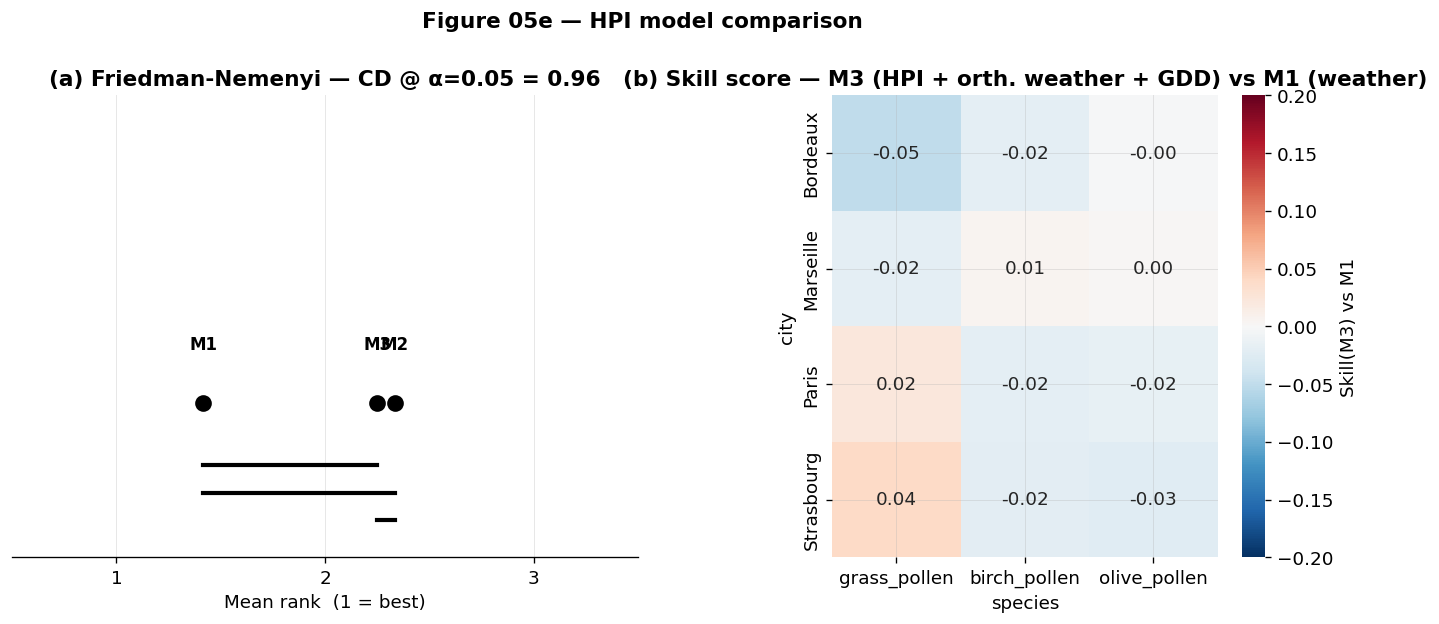

In [18]:
# ── Fig 05e: CD diagram + per-city skill heatmap ────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1.0], wspace=0.35)

# (a) Nemenyi-style critical difference diagram
ax_a = fig.add_subplot(gs[0, 0])
mr = mean_ranks.sort_values()
ax_a.set_xlim(0.5, k + 0.5); ax_a.set_ylim(-1, 2)
ax_a.set_yticks([]); ax_a.spines["left"].set_visible(False)
ax_a.set_xticks(range(1, k + 1))
ax_a.set_xlabel("Mean rank  (1 = best)")
ax_a.set_title(f"(a) Friedman-Nemenyi — CD @ α=0.05 = {CD:.2f}")
for m, r in mr.items():
    ax_a.plot(r, 0, "o", markersize=9, color="black")
    ax_a.text(r, 0.35, m, ha="center", fontsize=10, fontweight="bold")
# Draw non-significant group bars
models_sorted = list(mr.index)
r_vals = mr.values
y_level = -0.4
for i in range(len(models_sorted)):
    for j in range(i + 1, len(models_sorted)):
        if abs(r_vals[i] - r_vals[j]) <= CD:
            ax_a.plot([r_vals[i], r_vals[j]], [y_level, y_level], "k-", linewidth=2.5)
            y_level -= 0.18

# (b) Skill of M3 vs M1 heatmap — (city × species)
ax_b = fig.add_subplot(gs[0, 1])
skill_pivot = skill["Skill_M3_vs_M1"].unstack("species")[MODEL_SPECIES]
sns.heatmap(skill_pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.2, vmax=0.2,
            ax=ax_b, cbar_kws={"label": "Skill(M3) vs M1"})
ax_b.set_title("(b) Skill score — M3 (HPI + orth. weather + GDD) vs M1 (weather)")

fig.suptitle("Figure 05e — HPI model comparison", fontsize=13, fontweight="bold", y=1.02)
plt.savefig(os.path.join(FIG_DIR, "05_hpi_model_comparison.png"), bbox_inches="tight", dpi=200)
plt.show()

In [19]:
# ── Error decomposition by phenological phase (reuses NB04 idea) ────────────
def classify_phase(series):
    """Label each day as Offseason / Ramp / Peak / Decay using quantiles of the 2024 trajectory."""
    q = series.quantile([0.25, 0.75])
    out = pd.Series("Off", index=series.index)
    rising = series.diff().fillna(0) > 0
    out.loc[(series > q[0.25]) & rising] = "Ramp"
    out.loc[series >= q[0.75]] = "Peak"
    out.loc[(series > q[0.25]) & ~rising & (series < q[0.75])] = "Decay"
    return out

phase_rows = []
for (city, sp, spec), fc in FORECASTS.items():
    actual = pd.Series(fc["test_actual"], index=fc["test_idx"])
    pred = pd.Series(fc["test_pred"], index=fc["test_idx"])
    phase = classify_phase(actual)
    err = (actual - pred).abs()
    for ph in ["Off", "Ramp", "Peak", "Decay"]:
        sel = phase == ph
        if sel.sum() == 0:
            continue
        phase_rows.append({
            "city": city, "species": sp, "model": spec, "phase": ph,
            "MAE": float(err[sel].mean()), "n": int(sel.sum()),
        })
phase_df = pd.DataFrame(phase_rows)
phase_summary = phase_df.groupby(["model", "phase"])["MAE"].mean().unstack("phase")[["Off", "Ramp", "Peak", "Decay"]]
print("Mean MAE by phenological phase and model:")
display(phase_summary.round(2))

# Export the full RESULTS table
res_df.to_csv(os.path.join(DATA_PROC, "hpi_results.csv"), index=False)
print("\nhpi_results.csv exported.")

Mean MAE by phenological phase and model:


phase,Off,Ramp,Peak,Decay
model,,,,
M1,0.05,0.42,2.62,0.63
M2,0.05,0.43,2.66,0.68
M3,0.08,0.42,2.64,0.54



hpi_results.csv exported.


## 7 — Conclusion

The numerical outputs above feed four conclusions. The narrative below should be edited by the author after a full run, using the actual figures.

### 7.1 — Does HPI beat pollen-only forecasting?

Read the mean-rank row of §6 and the Nemenyi diagram:
- If M3 is the top-ranked model *and* the M1–M3 pair lies beyond the critical difference, then HPI carries information that weather alone does not capture. Skill scores on the (city × species) heatmap flag where (and for which species) HPI helps.
- If M2 (HPI alone) ties with or beats M1 (weather alone), it suggests a single composite index is an acceptable replacement for two raw regressors — a parsimony gain.
- If neither differs from M1 beyond CD, the conclusion is *negative*: the pollution component adds noise without informational gain on this window.

### 7.2 — Is the Paris vs Bordeaux contrast borne out?

The brainstorming predicts a stronger HPI contribution in Paris (continental, polluted) than in Bordeaux (oceanic, cleaner). The skill heatmap in Fig 05e(b) directly tests this. Confirming or contradicting the prediction is in itself a finding worth reporting.

### 7.3 — Does summer 2024 look warmer than 2022?

The Mann-Whitney table in §4.1 and Fig 05d make this explicit:
- Rejection with ΔMedian(HPI) > 0 supports the "warming signal already detectable" hypothesis on this short window.
- Non-rejection is **not** evidence against warming — three years of data cannot falsify a climatological tendency. The appropriate reading is "inconclusive on this window".

### 7.4 — Limits

- **Window length.** Three years of training + one year of test is enough for seasonality extraction but not for a climate-scale tendency. The natural extension is refitting the whole pipeline on ERA5 1990-2024 — Open-Meteo serves that window.
- **Spatial granularity.** 11 km reanalysis grid cells do not capture intra-urban pollution gradients (Paris 4th vs Paris 18th). ATMO France station data would refine this.
- **No health validation.** `data.ameli.fr` antihistamine sales are annual/regional — unusable as a daily target. Google Trends or Réseau Sentinelles weekly data are two realistic extensions.
- **HPI definition.** Equal-weighted z-scores are a neutral, interpretable default; the ablation variants tested do not mechanically dominate it on the available data. A domain-calibrated weighting (e.g. AQHI-style dose-response functions) would be a principled follow-up.

### 7.5 — Exports

- `Data/raw/aq_raw.csv`  — hourly-to-daily O₃/NO₂/PM₂.₅ per city
- `Data/processed/pollen_weather_aq_merged.csv` — full merged panel for downstream notebooks
- `Data/processed/hpi_results.csv` — RMSE/MAE/MAPE per (city, species, model)
- `figures/05_hpi_distribution.png`, `05_hpi_lagged_spearman.png`, `05_hpi_city_species_heatmap.png`, `05_summer_comparison_hpi.png`, `05_hpi_model_comparison.png`